In [120]:
import pandas as pd 
import numpy as np


import yfinance as y
import seaborn as sns 
import matplotlib.pyplot as plt

import warnings 
warnings.filterwarnings("ignore")

sns.set()


from pyspark.sql.window import Window
from pyspark.sql.functions import *


In [121]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ProjetoLocal") \
    .master("local[*]") \
    .getOrCreate()

spark.conf.set("spark.sql.repl.eagerEval.enabled", True)

# spark.conf.set("spark.sql.repl.eagerEval.maxNumRows", 100)
spark.conf.set("spark.sql.repl.eagerEval.truncate", 0)

# silenciando os avisos do spark
spark.sparkContext.setLogLevel("ERROR")



In [122]:
df = spark.read.parquet('../data/questionario_socioeconomico_2023.parquet', inferSchema=True)

In [123]:
mapeamento_colunas = {
    "Q001": "esc_pai",
    "Q002": "esc_mae",
    "Q003": "ocupacao_pai",
    "Q004": "ocupacao_mae",
    "Q005": "num_pessoas_residencia",
    "Q006": "renda_familiar",
    "Q007": "empregado_domestico",
    "Q008": "qtd_banheiros",
    "Q009": "qtd_quartos",
    "Q010": "tem_carro",
    "Q011": "tem_moto",
    "Q012": "tem_maquina_lavar",
    "Q013": "tem_geladeira",
    "Q014": "tem_freezer",
    "Q016": "tem_maquina_lavar_louca",
    "Q018": "tem_aspirador_po",
    "Q019": "tem_tv_cores",
    "Q021": "tem_tv_assinatura_dvd",
    "Q022": "qtd_celulares",
    "Q023": "tem_telefone_fixo",
    "Q024": "tem_computador",
    "Q025": "tem_internet"
}


df_renomeado = df
for coluna_antiga, coluna_nova in mapeamento_colunas.items():
    # Verifica se a coluna realmente existe no DataFrame antes de tentar renomear
    if coluna_antiga in df_renomeado.columns:
        df_renomeado = df_renomeado.withColumnRenamed(coluna_antiga, coluna_nova)

In [124]:
df_renomeado.count(), len(df_renomeado.columns)

(3933955, 22)

In [135]:
df_renomeado.limit(2)

esc_pai,esc_mae,ocupacao_pai,ocupacao_mae,num_pessoas_residencia,renda_familiar,empregado_domestico,qtd_banheiros,qtd_quartos,tem_carro,tem_moto,tem_maquina_lavar,tem_geladeira,tem_freezer,tem_maquina_lavar_louca,tem_aspirador_po,tem_tv_cores,tem_tv_assinatura_dvd,qtd_celulares,tem_telefone_fixo,tem_computador,tem_internet
"Completou o Ensino Médio, mas não completou a Faculdade.","Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.","Diarista, empregado doméstico, cuidador de idosos, babá, cozinheiro (em casas particulares), motorista particular, jardineiro, faxineiro de empresas e prédios, vigilante, porteiro, carteiro, office-boy, vendedor, caixa, atendente de loja, auxiliar administrativo, recepcionista, servente de pedreiro, repositor de mercadoria.","Diarista, empregada doméstica, cuidadora de idosos, babá, cozinheira (em casas particulares), motorista particular, jardineira, faxineira de empresas e prédios, vigilante, porteira, carteira, office-boy, vendedora, caixa, atendente de loja, auxiliar administrativa, recepcionista, servente de pedreiro, repositora de mercadoria.",4,"Até R$ 1.320,00",Não.,"Sim, um.","Sim, dois.",Não.,Não.,"Sim, uma.",Não.,Não.,"Sim, um.",Não.,"Sim, uma.",Não.,"Sim, um.",Não.,Não.,Sim.
"Completou o Ensino Médio, mas não completou a Faculdade.","Completou o Ensino Médio, mas não completou a Faculdade.","Padeiro, cozinheiro industrial ou em restaurantes, sapateiro, costureiro, joalheiro, torneiro mecânico, operador de máquinas, soldador, operário de fábrica, trabalhador da mineração, pedreiro, pintor, eletricista, encanador, motorista, caminhoneiro, taxista.",Não sei.,5,"Até R$ 1.320,00",Não.,"Sim, um.","Sim, dois.",Não.,Não.,"Sim, uma.","Sim, um.",Não.,Não.,Não.,"Sim, uma.",Não.,"Sim, dois.",Não.,Não.,Sim.


In [126]:

df_renomeado = (
    df_renomeado
        .withColumn('num_pessoas_residencia',
                    when(col('num_pessoas_residencia').contains(','),
                         split(col('num_pessoas_residencia'), ',' )[0] )
                         .otherwise(col('num_pessoas_residencia'))
                    )

        .withColumn('num_pessoas_residencia', col('num_pessoas_residencia').cast('int'))
    
)

In [ ]:
janela_quantidade = Window.orderBy(col('Quantidade').desc()) # UTILIZANDO PARA CALCULO CUMULATIVO
janela_geral = Window.rowsBetween(Window.unboundedPreceding, Window.unboundedFollowing) # UTILIZANDO PARA CALCULO GERAL

(
    df_renomeado
        .groupBy('renda_familiar').agg(
            count('*').alias('Quantidade')
        )
        
        .orderBy(col('Quantidade').desc())

        # .withColumn('Total', sum('Quantidade').over(janela_quantidade))
        .withColumn('Total_Geral', sum('Quantidade').over(janela_geral))

        .withColumn('Percentual', round(try_divide(col('Quantidade'), col('Total_Geral') ) * 100, 2)) # PERCENTUAL EM RELAÇÃO AO TOTAL
        .withColumn('Percentual_Acumulado', round(sum('Percentual').over(janela_quantidade), 2)) # PERCENTUAL CUMULATIVO
)

renda_familiar,Quantidade,Total_Geral,Percentual,Percentual_Acumulado
"Até R$ 1.320,00",1245271,3933955,31.65,31.65
"De R$ 1.320,01 até R$ 1.980,00.",650942,3933955,16.55,48.2
"De R$ 1.980,01 até R$ 2.640,00.",437366,3933955,11.12,59.32
"De R$ 2.640,01 até R$ 3.300,00.",293994,3933955,7.47,66.79
Nenhuma Renda,268053,3933955,6.81,73.6
"De R$ 3.960,01 até R$ 5.280,00.",261327,3933955,6.64,80.24
"De R$ 3.300,01 até R$ 3.960,00.",171344,3933955,4.36,84.6
"De R$ 5.280,01 até R$ 6.600,00.",139279,3933955,3.54,88.14
"De R$ 6.600,01 até R$ 7.920,00.",85970,3933955,2.19,90.33
"De R$ 7.920,01 até R$ 9240,00.",75179,3933955,1.91,92.24


In [139]:
df_renomeado.limit(1)

esc_pai,esc_mae,ocupacao_pai,ocupacao_mae,num_pessoas_residencia,renda_familiar,empregado_domestico,qtd_banheiros,qtd_quartos,tem_carro,tem_moto,tem_maquina_lavar,tem_geladeira,tem_freezer,tem_maquina_lavar_louca,tem_aspirador_po,tem_tv_cores,tem_tv_assinatura_dvd,qtd_celulares,tem_telefone_fixo,tem_computador,tem_internet
"Completou o Ensino Médio, mas não completou a Faculdade.","Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.","Diarista, empregado doméstico, cuidador de idosos, babá, cozinheiro (em casas particulares), motorista particular, jardineiro, faxineiro de empresas e prédios, vigilante, porteiro, carteiro, office-boy, vendedor, caixa, atendente de loja, auxiliar administrativo, recepcionista, servente de pedreiro, repositor de mercadoria.","Diarista, empregada doméstica, cuidadora de idosos, babá, cozinheira (em casas particulares), motorista particular, jardineira, faxineira de empresas e prédios, vigilante, porteira, carteira, office-boy, vendedora, caixa, atendente de loja, auxiliar administrativa, recepcionista, servente de pedreiro, repositora de mercadoria.",4,"Até R$ 1.320,00",Não.,"Sim, um.","Sim, dois.",Não.,Não.,"Sim, uma.",Não.,Não.,"Sim, um.",Não.,"Sim, uma.",Não.,"Sim, um.",Não.,Não.,Sim.


In [146]:
(
    df_renomeado


        .withColumn('tem_carro_temp',
                            when( col('tem_carro') == 'Sim, um.', 1)
                            .when(col('tem_carro') == 'Sim, dois.', 2)
                            .when(col('tem_carro') == 'Sim, três.', 3)
                            .when(col('tem_carro') == 'Sim, quatro ou mais.', 4)
                            .otherwise(0)
                )

        .select(
            col('tem_carro'),
            col('tem_carro_temp')
        )
        
        .distinct()
)

tem_carro,tem_carro_temp
"Sim, um.",1
"Sim, quatro ou mais.",4
"Sim, dois.",2
Não.,0
"Sim, três.",3


In [ ]:
(
    df_renomeado

        .withColumn('qtd_banheiros',
                    when( col('qtd_banheiros') == 'Sim, um.', 1)
                    .when(col('qtd_banheiros') == 'Sim, dois.', 2)
                    .when(col('qtd_banheiros') == 'Sim, três.', 3)
                    .when(col('qtd_banheiros') == 'Sim, quatro ou mais.', 4)
                    .otherwise(0)
        )


        .withColumn('qtd_quartos',
                            when( col('qtd_quartos') == 'Sim, um.', 1)
                            .when(col('qtd_quartos') == 'Sim, dois.', 2)
                            .when(col('qtd_quartos') == 'Sim, três.', 3)
                            .when(col('qtd_quartos') == 'Sim, quatro ou mais.', 4)
                            .otherwise(0)
                )


        .withColumn('tem_carro_temp',
                                    when( col('tem_carro') == 'Sim, um.', 1)
                                    .when(col('tem_carro') == 'Sim, dois.', 2)
                                    .when(col('tem_carro') == 'Sim, três.', 3)
                                    .when(col('tem_carro') == 'Sim, quatro ou mais.', 4)
                                    .otherwise(0)
                        )


        .groupBy('renda_familiar').agg(
            round(avg('qtd_banheiros'),2).alias('percent_banheiro'),
            round(avg('qtd_quartos'),2).alias('qtd_quartos')
        )

        .orderBy(col('percent_banheiro').desc())

)

renda_familiar,percent_banheiro,qtd_quartos
"Acima de R$ 26.400,00.",3.46,3.37
"De R$ 19.800,01 até R$ 26.400,00.",3.12,3.15
"De R$ 15.840,01 até R$19.800,00.",2.9,3.06
"De R$ 13.200,01 até R$ 15.840,00.",2.73,2.99
"De R$ 11.880,01 até R$ 13.200,00.",2.56,2.92
"De R$ 10.560,01 até R$ 11.880,00.",2.54,2.92
"De R$ 9.240,01 até R$ 10.560,00.",2.44,2.87
"De R$ 7.920,01 até R$ 9240,00.",2.24,2.8
"De R$ 6.600,01 até R$ 7.920,00.",2.09,2.74
"De R$ 5.280,01 até R$ 6.600,00.",1.99,2.69


In [128]:
df_residencias = (
    df_renomeado
        .sample(withReplacement=False, fraction=0.05, seed=123)


        .select(
            col('num_pessoas_residencia')
        )  
).toPandas()

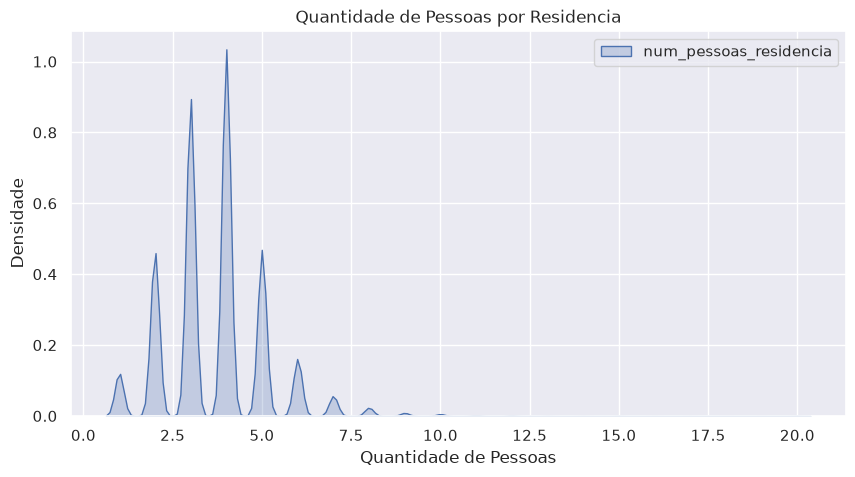

In [129]:
plt.figure(figsize=(10,5))
plt.title('Quantidade de Pessoas por Residencia')
sns.kdeplot(data=df_residencias, fill=True)
plt.xlabel('Quantidade de Pessoas')
plt.ylabel('Densidade')
plt.show()